Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

Imagen y tranformaciones necesarias para la realización de las tareas

In [2]:
img = cv2.imread('assets/mandril.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 60, 200)

ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y

#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

sobel8 = cv2.convertScaleAbs(sobel)


TAREA 1: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

57885
Filas resaltadas (índices): [12, 15, 20, 100] Número de filas resaltadas: 4
Maximo de píxeles blancos por fila: 227


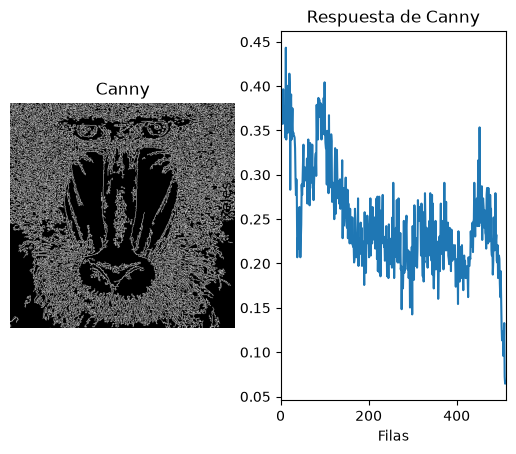

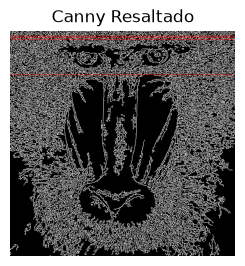

In [ ]:
# Cuenta el número de píxeles blancos (255) por fila
# Suma los valores de los pixeles por fila
rows_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
# Valor maximo
maximo = np.max(rows_counts)
maxfil = maximo // 255
print(maximo)

canny_resaltado = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)

# Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
# El resultado será el número de píxeles blancos por fila
rows = np.zeros((rows_counts.shape[0], 1), dtype=np.float32)

filas_posiciones = []
for i in range(rows_counts.shape[0]):
    # Resalta las filas que superan el 90% del valor máximo de píxeles blancos
    if (maximo * 0.9 <= rows_counts[i][0]):
        filas_posiciones.append(i)  # Guardar la posición de la fila resaltada
        cv2.line(canny_resaltado, (0, i), (canny.shape[1]-1, i), (255, 0, 0), 1)  # Dibuja línea azul en la fila resaltada

    rows[i][0] = (rows_counts[i][0] / (255 * canny.shape[1]))

print("Filas resaltadas (índices):", filas_posiciones, "Número de filas resaltadas:", len(filas_posiciones))
print("Maximo de píxeles blancos por fila:", maxfil)

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
#Rango en x definido por las filas
plt.xlim([0, canny.shape[0]])

plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny Resaltado")
plt.imshow(canny_resaltado) 

TAREA 2: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?


### Análisis y Comparación de Resultados: Sobel vs. Canny

* **Operador Sobel (tras umbralizado):** El gradiente calculado por Sobel resalta los cambios de intensidad, pero al aplicar un umbral manual directo sobre los valores de 8 bits, los bordes resultantes tienden a ser **gruesos y difusos**. Esto se debe a que la respuesta del gradiente se extiende a lo largo de varios píxeles en las zonas de transición y el operador por sí solo no realiza una compresión del grosor de la línea, lo que también lo hace más propenso a mantener ruido residual.
* **Operador Canny:** Proporciona una detección de bordes significativamente más refinada. Debido a sus etapas internas de optimización, específicamente la **supresión de no-máximos** (que afina los bordes hasta dejar un grosor de un solo píxel) y el **umbralizado por histéresis**, Canny aísla las estructuras principales de forma limpia, conectando los contornos verdaderos y suprimiendo el ruido de fondo de manera mucho más eficiente que un umbralizado simple sobre Sobel.

Máximo de píxeles blancos por columna: 293
Columnas resaltadas (índices): [103, 104, 105, 106, 107, 108, 112, 125, 126, 127, 128, 132, 287, 288] 
Número de columnas resaltadas: 14

Máximo de píxeles blancos por fila: 76500
Filas resaltadas (índices): [1, 2, 3, 4, 5, 6, 8, 9, 11, 12, 19, 20, 24, 25, 82, 83, 84, 85, 87, 99, 100] 
Número de filas resaltadas: 21


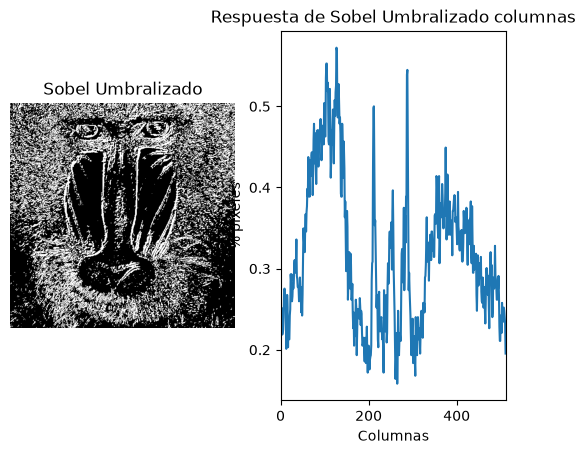

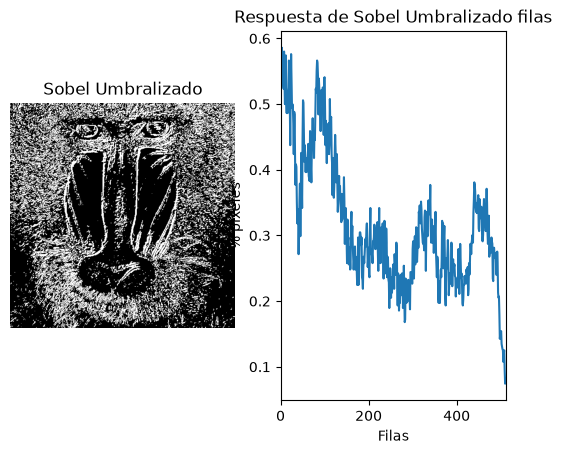

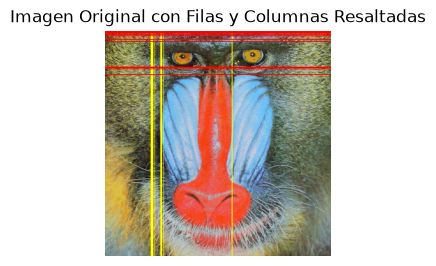

In [ ]:
# Define valor umbral
valorUmbral = 70

# Imagen umbralizada para dicho valor definido
_, sobel8Umbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)

# Conteo por filas y columnas de la imagen umbralizada

sobel8Umbralizado_resaltado = cv2.cvtColor(sobel8Umbralizada, cv2.COLOR_GRAY2RGB)

# Columnas 
col_counts = cv2.reduce(sobel8Umbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols = col_counts[0] / (255 * sobel8Umbralizada.shape[0])

maximo_col = np.max(col_counts)
maxfil_col = maximo_col // 255
print("Máximo de píxeles blancos por columna:", maxfil_col)

filas_posiciones_col = []

for i in range(col_counts.shape[1]):
    # Resalta las filas que superan el 90% del valor máximo de píxeles blancos
    if (maximo_col * 0.9 <= col_counts[0][i]):
        filas_posiciones_col.append(i)  # Guardar la posición de la fila resaltada
        cv2.line(img, (i, 0), (i, sobel8Umbralizada.shape[0]-1), (255, 255, 0), 1)  # Dibuja línea amarilla en la fila resaltada

print("Columnas resaltadas (índices):", filas_posiciones_col, "\nNúmero de columnas resaltadas:", len(filas_posiciones_col))


plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel Umbralizado")
plt.imshow(sobel8Umbralizada, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Sobel Umbralizado columnas")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)
#Rango en x definido por las columnas
plt.xlim([0, sobel8Umbralizada.shape[1]])



# Filas 
rows_counts = cv2.reduce(sobel8Umbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Valor maximo
maximo_row = np.max(rows_counts)
maxfil_row = maximo_row // 255
print("\nMáximo de píxeles blancos por fila:", maximo_row)

# Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
# El resultado será el número de píxeles blancos por fila
rows = np.zeros((rows_counts.shape[0], 1), dtype=np.float32)
filas_posiciones_row = []
for i in range(rows_counts.shape[0]):
    # Resalta las filas que superan el 90% del valor máximo de píxeles blancos
    if (maximo_row * 0.9 <= rows_counts[i][0]):
        filas_posiciones_row.append(i)  # Guardar la posición de la fila resaltada
        cv2.line(img, (0, i), (sobel8Umbralizada.shape[1]-1, i), (255, 0, 0), 1)  # Dibuja línea en la fila resaltada

    rows[i][0] = (rows_counts[i][0] / (255 * sobel8Umbralizada.shape[1]))

print("Filas resaltadas (índices):", filas_posiciones_row, "\nNúmero de filas resaltadas:", len(filas_posiciones_row))

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel Umbralizado")
plt.imshow(sobel8Umbralizada, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Sobel Umbralizado filas")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
#Rango en x definido por las filas
plt.xlim([0, sobel8Umbralizada.shape[0]])

plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Imagen Original con Filas y Columnas Resaltadas")
plt.imshow(img) 



TAREA 3: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [5]:
vid = cv2.VideoCapture(0)

ret, frame_anterior = vid.read()
if ret:
    gris_anterior = cv2.cvtColor(frame_anterior, cv2.COLOR_BGR2GRAY)
    # Desenfoque gaussiano para reducir ruido en la imagen
    gris_anterior = cv2.GaussianBlur(gris_anterior, (21, 21), 0)

while True:
    ret, frame = vid.read()
    if not ret:
        break
    
    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gris = cv2.GaussianBlur(gris, (21, 21), 0)
    
    # Detección de movimiento por diferencia absoluta entre fotogramas
    resta = cv2.absdiff(gris_anterior, gris)
    
    # Binarización y dilatación para aislar y agrupar los píxeles en movimiento
    _, umbral = cv2.threshold(resta, 25, 255, cv2.THRESH_BINARY)
    umbral = cv2.dilate(umbral, None, iterations=2)
    
    # Búsqueda de contornos externos
    contornos, _ = cv2.findContours(umbral, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Preparación del lienzo en Pillow (RGB) para el renderizado del texto
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(frame_rgb)
    draw = ImageDraw.Draw(img_pil)
    

    if contornos:
        # Identificar el contorno de mayor tamaño
        contorno_max = max(contornos, key=cv2.contourArea)
        
        # Ignorar movimientos minúsculos para evitar parpadeos por ruido
        if cv2.contourArea(contorno_max) > 1500: 
            # Extraer las coordenadas del rectángulo delimitador (bounding box)
            (x, y, w, h) = cv2.boundingRect(contorno_max)
            
            # Renderizado del bloque de privacidad
            draw.rectangle(((x, y), (x + w, y + h)), fill="black")
            
    # Conversión inversa a BGR para visualización correcta en OpenCV
    frame_final = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    frame_final_volteado = cv2.flip(frame_final, 1)  # Voltear horizontalmente para efecto espejo


    # Actualizar el frame de referencia para la próxima iteración
    gris_anterior = gris.copy()

    cv2.imshow('My Little Piece of Privacy - Digital', frame_final_volteado)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

In [6]:
vid = cv2.VideoCapture(0)

ret, frame_anterior = vid.read()
if ret:
    gris_anterior = cv2.cvtColor(frame_anterior, cv2.COLOR_BGR2GRAY)
    # Desenfoque gaussiano para reducir ruido en la imagen
    gris_anterior = cv2.GaussianBlur(gris_anterior, (21, 21), 0)

while True:
    ret, frame = vid.read()
    if not ret:
        break
    
    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gris = cv2.GaussianBlur(gris, (21, 21), 0)
    
    # Detección de movimiento por diferencia absoluta entre fotogramas
    resta = cv2.absdiff(gris_anterior, gris)
    
    # Binarización y dilatación para aislar y agrupar los píxeles en movimiento
    _, umbral = cv2.threshold(resta, 25, 255, cv2.THRESH_BINARY)
    umbral = cv2.dilate(umbral, None, iterations=2)
    
    # Búsqueda de contornos externos
    contornos, _ = cv2.findContours(umbral, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Preparación del lienzo en Pillow (RGB) para el renderizado del texto
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(frame_rgb)
    draw = ImageDraw.Draw(img_pil)
    

    if contornos:
        # Identificar el contorno de mayor tamaño
        contorno_max = max(contornos, key=cv2.contourArea)
        
        # Ignorar movimientos minúsculos para evitar parpadeos por ruido
        if cv2.contourArea(contorno_max) > 1500: 
            # Extraer las coordenadas del rectángulo delimitador (bounding box)
            (x, y, w, h) = cv2.boundingRect(contorno_max)
            
            # Renderizado del bloque de privacidad
            # Dibujamos una cara de payaso cuando se mueve algo en la cámara
            draw.circle((x , y), h+100, fill="brown")  # Dibuja un círculo blanco como fondo
            draw.circle((x + w//2, y + h - 200), min(w, h)//4, fill="black")  # Dibuja un circulo azul como ojo arriba de la nariz
            draw.circle((x - w//2, y + h - 200), min(w, h)//4, fill="black")  # Dibuja un circulo azul como ojo arriba de la nariz
            draw.polygon([(x - w//2, y + h - 100), (x + w//2, y + h - 100), (x, y + h)], fill="orange")  # Dibuja un triángulo rojo como nariz
            draw.arc([(x - w//2, y + h - 50), (x + w//2, y + h + 50)], start=0, end=180, fill="black", width=6)  # Dibuja un arco rojo como sonrisa
            draw.line([(x - w//2, y + h - 70), (x - w, y + h - 100)], fill="black", width=3)  # Bigote izquierdo
            draw.line([(x + w//2, y + h - 70), (x + w, y + h - 100)], fill="black", width=3)  # Bigote derecho
            draw.line([(x - w//2, y + h - 50), (x - w, y + h - 50)], fill="black", width=3)  # Bigote izquierdo
            draw.line([(x + w//2, y + h - 50), (x + w, y + h - 50)], fill="black", width=3)  # Bigote derecho
            draw.line([(x - w//2, y + h - 25), (x - w, y + h)], fill="black", width=3)  # Bigote izquierdo
            draw.line([(x + w//2, y + h - 25), (x + w, y + h)], fill="black", width=3)  # Bigote derecho

            

            
            
    # Conversión inversa a BGR para visualización correcta en OpenCV
    frame_final = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    frame_final_volteado = cv2.flip(frame_final, 1)  # Voltear horizontalmente para efecto espejo


    # Actualizar el frame de referencia para la próxima iteración
    gris_anterior = gris.copy()

    cv2.imshow('My Little Piece of Privacy - Digital', frame_final_volteado)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

In [7]:
import winsound

vid = cv2.VideoCapture(0)

# Primer fotograma de referencia
_, frame_ant = vid.read()
gris_ant = cv2.cvtColor(frame_ant, cv2.COLOR_BGR2GRAY)

try:
    fuente = ImageFont.truetype("arial.ttf", 32)
except IOError:
    fuente = ImageFont.load_default()
espera_sonido = 0  # Evita que el sonido se repita en cada fotograma continuo

while True:
    ret, frame = vid.read()
    if not ret:
        break

    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Diferencia entre fotogramas y binarización
    resta = cv2.absdiff(gris_ant, gris)
    _, mascara = cv2.threshold(resta, 30, 255, cv2.THRESH_BINARY)

    # Conteo directo de píxeles blancos en movimiento
    pixeles_mov = cv2.countNonZero(mascara)

    # Alarma si se superan 50.000 píxeles activos
    alerta = pixeles_mov > 50000

    if alerta:
        if espera_sonido == 0:
            winsound.PlaySound("assets/alert.wav", winsound.SND_FILENAME | winsound.SND_ASYNC)  # Sonido de alerta sin congelar el vídeo
            espera_sonido = 25      # Espera 25 fotogramas antes de volver a pitar

        # Marco rojo exterior de aviso
        cv2.rectangle(frame, (0, 0), (frame.shape[1] - 1, frame.shape[0] - 1), (0, 0, 255), 20)

    if espera_sonido > 0:
        espera_sonido -= 1

    # Texto informativo con Pillow
    img_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    texto = "¡ALERTA: MUCHO MOVIMIENTO!" if alerta else f"Pixeles activos: {pixeles_mov}"
    color_texto = "red" if alerta else "black"
    draw.text((20, 20), texto, font=fuente, fill=color_texto)
    frame_final = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

    gris_ant = gris
    cv2.imshow("Alarma de Movimiento", frame_final)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()